In [183]:
# importing the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [184]:
# loading the csv file
df = pd.read_csv("video_games_sales_data.csv")
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [185]:
# printing columns of the datatset.
print(df.columns)

Index(['img', 'title', 'console', 'genre', 'publisher', 'developer',
       'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales',
       'other_sales', 'release_date', 'last_update'],
      dtype='object')


In [186]:
# information about the datatset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [187]:
# shape of the datatset
print(df.shape)

(64016, 14)


In [188]:
# checking for null values
print(df.isna().sum())

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64


In [189]:
# first selecting the numerical columns
numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
print(numerical_cols)

['critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales']


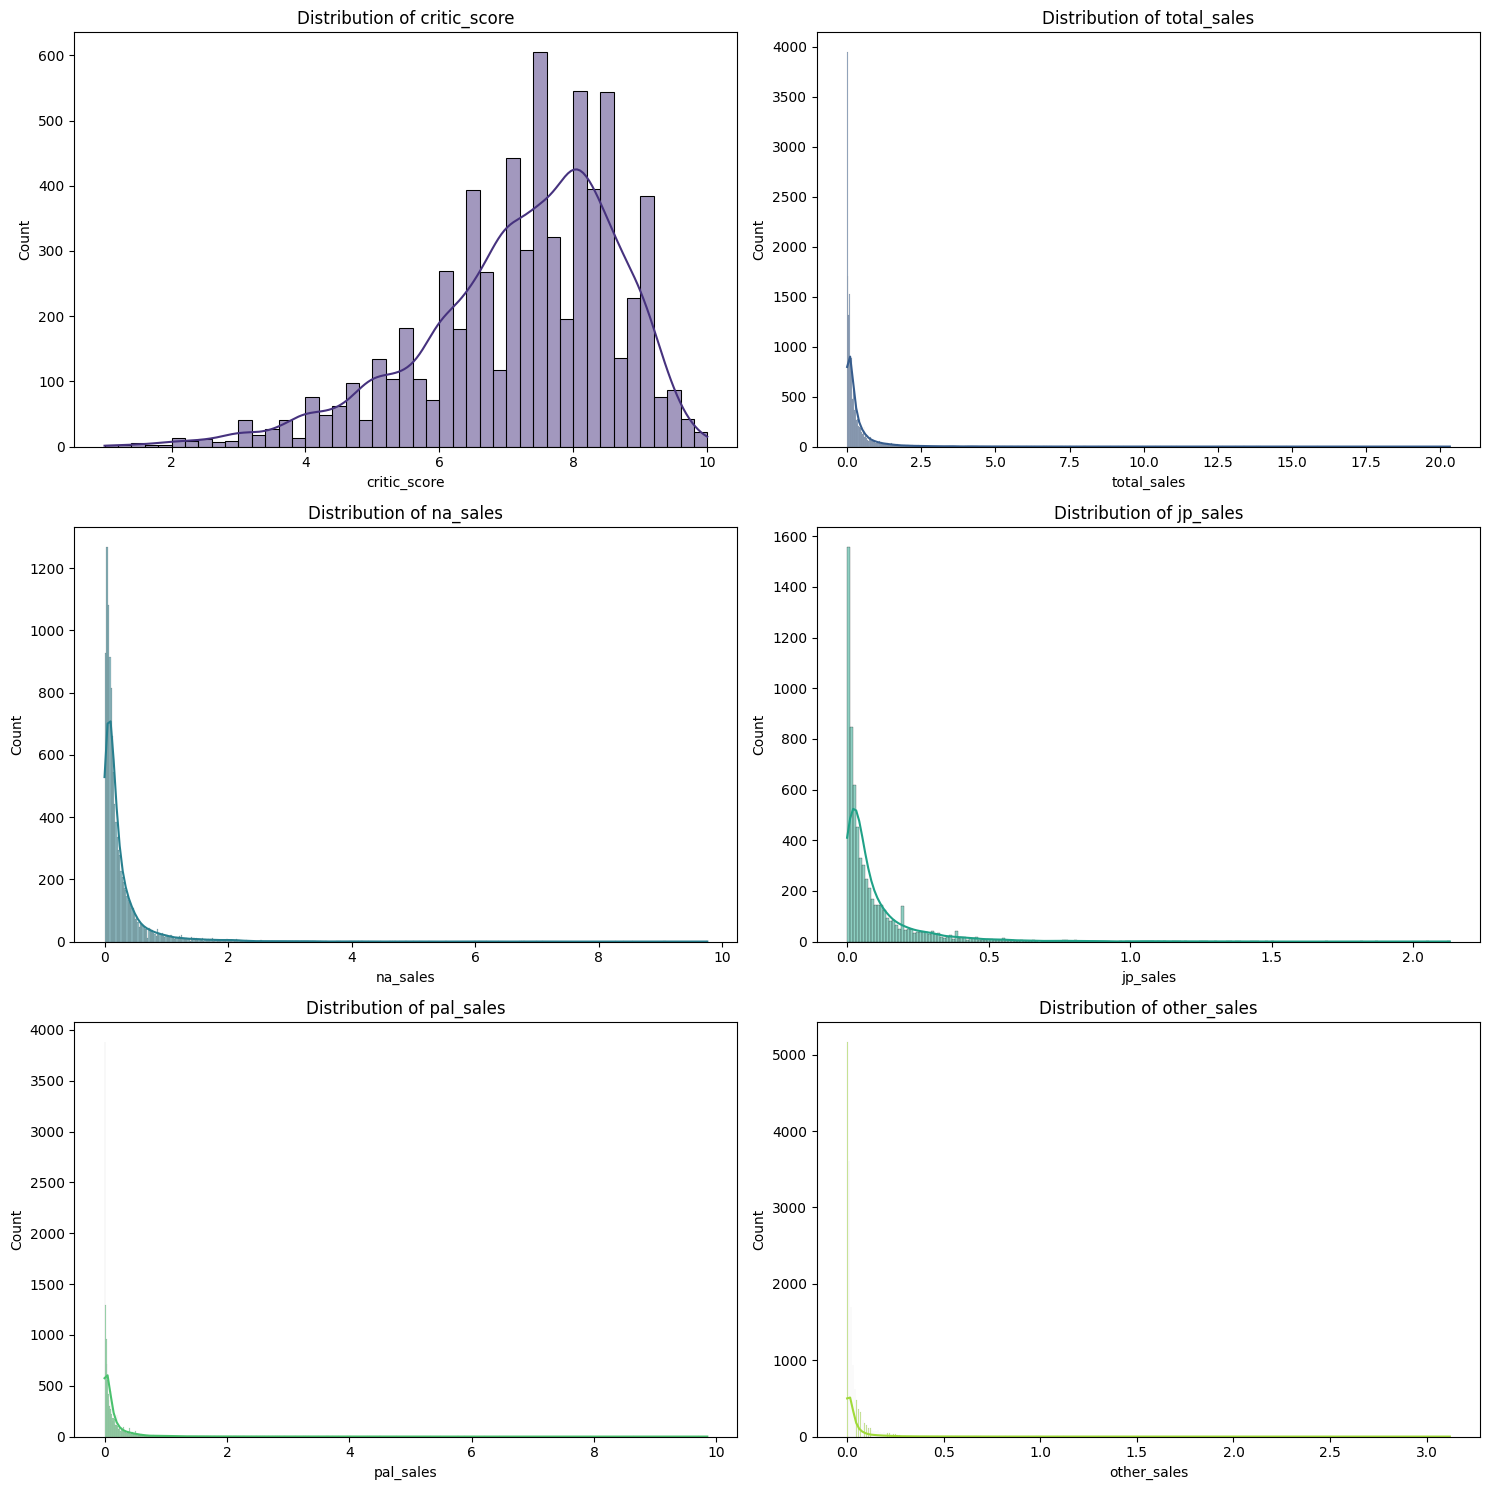

In [190]:
num_cols = len(numerical_cols)
num_rows = (num_cols + 1) // 2  # calculate number of rows, 2 columns per row

fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))
axes = axes.flatten() # flatten the array of axes for easy iteration

palette = sns.color_palette("viridis", n_colors=num_cols)

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color=palette[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# removing any unuse subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Based on our observation, we will use median to fill the missing values. The distributions are highly skewed and median would work better.

In [191]:
# filling the missing values with the median
for col in numerical_cols:
    median_value = df[col].median()
    df[col].fillna(median_value,inplace=True)

In [192]:
# checking the missing values again
print(df.isna().sum())

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score        0
total_sales         0
na_sales            0
jp_sales            0
pal_sales           0
other_sales         0
release_date     7051
last_update     46137
dtype: int64


In [193]:
# checking for any duplicate values
print(df.duplicated().sum())

0


In [194]:
# extracting release year from release date
df['release_year'] = df['release_date'].str.strip().str[0:4]
df.head(5)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update,release_year
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN,2013
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03,2014
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN,2002
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,7.5,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN,2013
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14,2015


In [195]:
# now dropping ['release date','last update'] columns. Do not add any value
df.drop(['release_date','last_update'],axis=1,inplace=True)
print(df.columns)

Index(['img', 'title', 'console', 'genre', 'publisher', 'developer',
       'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales',
       'other_sales', 'release_year'],
      dtype='object')


In [196]:
# converting the release year column to numeric
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')

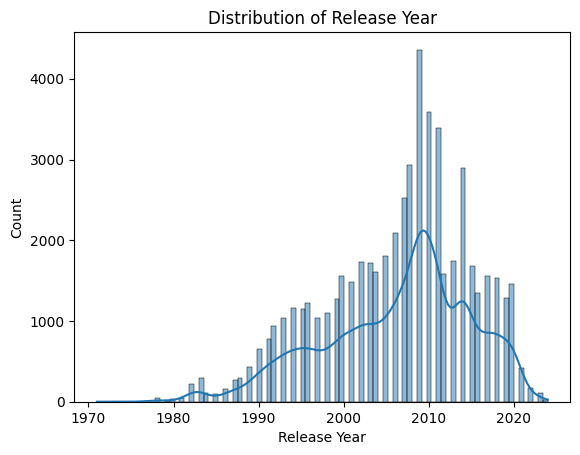

In [197]:
# checking the distribution of release year
sns.histplot(df['release_year'].dropna(), kde=True)
plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

In [198]:
# now filling the missing values in release year column with median
median_value = df['release_year'].median()
df['release_year'] = df['release_year'].fillna(median_value)

In [199]:
df.isna().sum()

,0
img,0
title,0
console,0
genre,0
publisher,0
developer,17
critic_score,0
total_sales,0
na_sales,0
jp_sales,0


In [200]:
# removing nulls from developer
df = df.dropna(subset=['developer'])

Publisher has 3,383 unique values, developer has 8,862. One-hot encoding those raw invites memorization, not generalization. Collapse rare categories into "Other".

In [201]:
def bucket_rare_categories(df, column, threshold=20):
    counts = df[column].value_counts()
    rare = counts[counts < threshold].index
    df[column + '_grouped'] = df[column].where(~df[column].isin(rare), 'Other')
    return df

df = bucket_rare_categories(df, 'publisher', threshold=20)
df = bucket_rare_categories(df, 'developer', threshold=20)

In [202]:
df['publisher_grouped'].value_counts()

,count
publisher_grouped,
Other,10733
Unknown,8833
Sega,2207
Ubisoft,1662
Electronic Arts,1619
...,...
Enjoy Gaming ltd.,20
Fabio Ricci,20
TikGames,20


In [203]:
# now selecting features and target
features = ['critic_score', 'console', 'genre', 'publisher_grouped', 'developer_grouped', 'release_year']
X = df[features]
y = df['total_sales']

In [204]:
from sklearn.model_selection import train_test_split
# splitting the data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape) # shape of X_train
print(y_train.shape) # shape of y_train

(51199, 6)
(51199,)


In [205]:
# now preprocessing the pipeline
# using One Hot Encoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['console', 'genre', 'publisher_grouped', 'developer_grouped']
numerical_features = ['critic_score', 'release_year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ]
)

Baseline model: Linear Regression

In [206]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — RMSE: {lr_rmse:.4f}, R2: {lr_r2:.4f}")

Linear Regression — RMSE: 0.4044, R2: 0.1154


Comparison Model - Random Forest

In [207]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print(f"Random Forest — RMSE: {rf_rmse:.4f}, R2: {rf_r2:.4f}")

Random Forest — RMSE: 0.3535, R2: 0.3239


In [208]:
# now comparing side by side
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [lr_rmse, rf_rmse],
    'R2': [lr_r2, rf_r2]
})
print(results)

               Model      RMSE        R2
0  Linear Regression  0.404377  0.115430
1      Random Forest  0.353524  0.323922


Feature Importance (Random Forest)

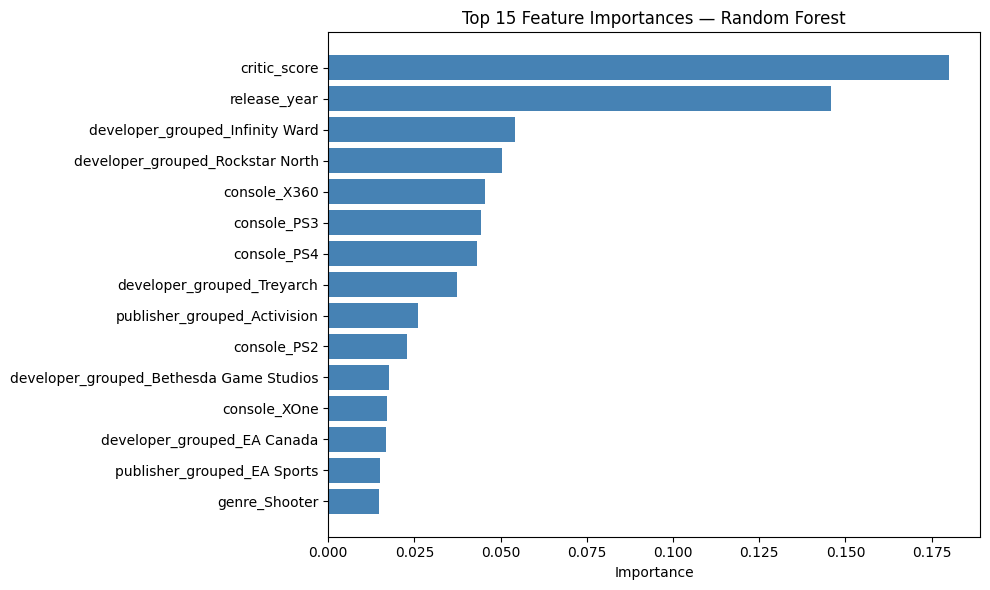

In [209]:
ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

importances = rf_pipeline.named_steps['regressor'].feature_importances_

feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()